# Implement the Multi-lanes Code

In [1]:
%run ../Lanes_copy.ipynb

Test 1: Empty Road
  Expected flow = 0, Actual flow = 1.6
  Expected jam fraction = 0, Actual jam fraction = 0.0
  FAIL

Test 2: Full Road
  Expected jam fraction = 1, Actual jam fraction = 1.000
  PASS
Totoal Average Flow: 0.005970297029702975
Total Jamming Fraction: 0.0019801980198019802
[[ 5]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 

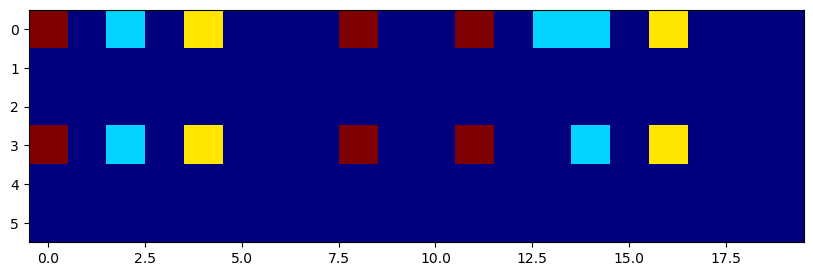

In [2]:
# Check the state of the grid at a specific time step

import matplotlib.pyplot as plt

model = Multi_Lane_Traffic(cells=20, lanes=6, density=0.2, vmax=5, p=0.2, random_state=None)
model.simulate(100)

t = model.history[81]
plt.figure(figsize=(10, 6))
plt.imshow(t, cmap='jet')

In [3]:
# Optimized Multi-Lane Traffic Model with Colored Cars
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import HTML

class Multi_Lane_Traffic_Colored:
    def __init__(self, cells=10, lanes=10, density=0, vmax=5, p=0.3, random_state=None):
        self.cells = cells
        self.lanes = lanes
        self.vmax = vmax
        self.p = p
        
        if random_state is not None:
             np.random.seed(random_state)
        
        # Two Grids: One for Speed, One for ID
        self.grid = -1 * np.ones((lanes, cells), dtype=int)
        self.id_grid = -1 * np.ones((lanes, cells), dtype=int)
        
        self.history = []     # Stores velocity grids
        self.id_history = []  # Stores ID grids

    def get_gap(self, grid, lane, cell):
        """Calculate empty cells ahead in a specific lane"""
        gap = 0
        for i in range(1, self.vmax + 2):
            next_cell = (cell + i) % self.cells
            if grid[lane][next_cell] != -1:
                return gap
            gap += 1
        return gap

    def step(self):
        current_grid = self.grid.copy()
        current_ids = self.id_grid.copy()
        # Divide the phase into two parts: intermediate grid for lane switching and final grid for motion
        # Add intermediate grids for lane switching to make sure every car locates in their correct position
        intermediate_grid = -1 * np.ones_like(current_grid)
        intermediate_ids = -1 * np.ones_like(current_ids)
        # Final grid after following the motion rule
        new_grid = -1 * np.ones_like(current_grid)
        new_ids = -1 * np.ones_like(current_ids)
        
        # Cars look at gaps in adjacent lanes and decide whether to switch lanes
        for lane in range(self.lanes):
            for cell in range(self.cells):
                vel = current_grid[lane][cell]
                car_id = current_ids[lane][cell]
                if vel == -1: continue 
                
                gap = self.get_gap(current_grid, lane, cell)
                desired_v = min(vel + 1, self.vmax)
                target_lane = lane
                
                # Try to switch if blocked
                if gap < desired_v:
                    left_lane = (lane - 1) % self.lanes
                    if current_grid[left_lane][cell] == -1:
                        left_gap = self.get_gap(current_grid, left_lane, cell)
                        if left_gap > gap:
                            target_lane = left_lane
                            gap = left_gap 
                    
                    if target_lane == lane:
                        right_lane = (lane + 1) % self.lanes
                        if current_grid[right_lane][cell] == -1:
                            right_gap = self.get_gap(current_grid, right_lane, cell)
                            if right_gap > gap:
                                target_lane = right_lane
                
                # Place the car in the intermediate grid at the same cell
                # Move BOTH velocity and ID to the intermediate grid
                intermediate_grid[target_lane][cell] = vel
                intermediate_ids[target_lane][cell] = car_id

        # Now cars are in their new lanes, and apply the motion rules (acceleration, deceleration, randomization, movement)
        for lane in range(self.lanes):
            for cell in range(self.cells):
                vel = intermediate_grid[lane][cell]
                car_id = intermediate_ids[lane][cell]
                if vel == -1: continue
                
                
                gap = self.get_gap(intermediate_grid, lane, cell)
                if vel < self.vmax: vel += 1
                if vel > gap: vel = gap
                if vel > 0 and np.random.rand() < self.p: vel -= 1
                
                new_pos = (cell + vel) % self.cells
                
                # Update BOTH grids at the new position
                new_grid[lane][new_pos] = vel
                new_ids[lane][new_pos] = car_id
        
        self.grid = new_grid
        self.id_grid = new_ids
        
        self.history.append(self.grid.copy())
        self.id_history.append(self.id_grid.copy())

    def simulate(self, n_step):
        self.history = [self.grid.copy()]
        self.id_history = [self.id_grid.copy()]
        for _ in range(n_step):
            self.step()

# Visualization

## Simple Test, single line

In [17]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import HTML
import numpy as np

# Lane = 1
model = Multi_Lane_Traffic_Colored(cells=10, lanes=1, density=0, vmax=5, p=0.2, random_state=42)
# Here, we manually place cars to track specific IDs so we can ensure that the cars moving correctly. Later, we will use the colors representing their speed.
# Place 5 Cars with unique IDs so we follow specific cars
initial_positions = [0, 1, 2, 3, 4]
for i, pos in enumerate(initial_positions):
    model.grid[0][pos] = 5        # Speed = 5
    model.id_grid[0][pos] = i + 1 # ID = 1, 2, 3, 4, 5

model.simulate(30)
fig, ax = plt.subplots(figsize=(10, 2))
colors = ['#333333', '#FF0000', '#FFA500', '#FFFF00', '#00FF00', "#0059FF"]
cmap = ListedColormap(colors)


def update(frame_idx):
    ax.clear()
    
    # Get Data

    vel_grid = np.array(model.history[frame_idx])
    id_grid = np.array(model.id_history[frame_idx])
    ax.imshow(id_grid, cmap=cmap, aspect='auto', vmin=-1, vmax=6)
    
    
    #Put the cars on the grid with their speed values
    rows, cols = vel_grid.shape
    for l in range(rows):
        for c in range(cols):
            if id_grid[l][c] != -1:
                speed_val = vel_grid[l][c]
                ax.text(c, l, str(speed_val), ha='center', va='center', 
                        color='black', fontweight='bold', fontsize=12)

    
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
    ax.tick_params(which='minor', bottom=False, left=False)
    ax.set_yticks([0])
    ax.set_yticklabels(["Lane 0"])
    
    ax.set_title(f"Single Lane Simulation - Step {frame_idx} (Color by car ID)")

ani = animation.FuncAnimation(fig, update, frames=len(model.history), interval=500)
ani.save('single_lane_simulation.gif', writer='pillow', fps=2)

plt.close()

display(HTML(ani.to_jshtml()))

## Multiple Cars in the larger grids

## 10 cars

In [12]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import HTML
import numpy as np

model = Multi_Lane_Traffic_Colored(cells=20, lanes=6, density=0, vmax=5, p=0.2, random_state=42)

np.random.seed(123) 
cars_placed = 0
#set the number of cars = 10
#code will place 10 cars randomly in the grid
while cars_placed < 10: 
    l = np.random.randint(0, 6)
    c = np.random.randint(0, 20)
    if model.grid[l][c] == -1:
        model.grid[l][c] = np.random.randint(1, 6)
        model.id_grid[l][c] = cars_placed + 1 
        cars_placed += 1

model.simulate(100)

fig, ax = plt.subplots(figsize=(10, 5))

# Define colors based on corresponding velocity (0 to 5)
# -1: Empty (Grey)
#
colors = [
    '#333333',  # vel = -1: Empty Road
    '#FF0000',  # vel =  0
    '#FF8C00',  # vel =  1
    '#FFD700',  # vel =  2
    '#ADFF2F',  # vel =  3
    '#00BFFF',  # vel =  4
    '#0000FF'   # vel =  5
]

cmap = ListedColormap(colors)
# Similar plotting code as before but now color by velocity
def update(frame_idx):
    ax.clear()
    vel_grid = np.array(model.history[frame_idx])
    ax.imshow(vel_grid, cmap=cmap, aspect='auto')
    rows, cols = np.where(vel_grid != -1)
    for l, c in zip(rows, cols):
        val = vel_grid[l][c]
        ax.text(c, l, str(val), ha='center', va='center', 
                color='white', fontweight='bold', fontsize=8)

    ax.set_xticks(np.arange(-0.5, model.cells, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, model.lanes, 1), minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)
    
    ax.set_title(f"Step {frame_idx} (Color by Velocity)")

ani = animation.FuncAnimation(fig, update, frames=len(model.history), interval=200)
plt.close()
ani.save('10 cars in multilanes.gif', writer='pillow', fps=2)
display(HTML(ani.to_jshtml()))

## 30 cars in the same grid

In [11]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import HTML
import numpy as np

model = Multi_Lane_Traffic_Colored(cells=20, lanes=6, density=0, vmax=5, p=0.2, random_state=42)

np.random.seed(123) 
cars_placed = 0
#Same code as before but with different number of cars
#set the number of cars = 30
#code will place 10 cars randomly in the grid
while cars_placed < 30: 
    l = np.random.randint(0, 6)
    c = np.random.randint(0, 20)
    if model.grid[l][c] == -1:
        model.grid[l][c] = np.random.randint(1, 6)
        model.id_grid[l][c] = cars_placed + 1 
        cars_placed += 1

model.simulate(100)

fig, ax = plt.subplots(figsize=(10, 5))

# Define colors based on corresponding velocity (0 to 5)
# -1: Empty (Grey)
#
colors = [
    '#333333',  # vel = -1: Empty Road
    '#FF0000',  # vel =  0
    '#FF8C00',  # vel =  1
    '#FFD700',  # vel =  2
    '#ADFF2F',  # vel =  3
    '#00BFFF',  # vel =  4
    '#0000FF'   # vel =  5
]

cmap = ListedColormap(colors)

def update(frame_idx):
    ax.clear()
    vel_grid = np.array(model.history[frame_idx])
    ax.imshow(vel_grid, cmap=cmap, aspect='auto')
    rows, cols = np.where(vel_grid != -1)
    for l, c in zip(rows, cols):
        val = vel_grid[l][c]
        ax.text(c, l, str(val), ha='center', va='center', 
                color='white', fontweight='bold', fontsize=8)

    ax.set_xticks(np.arange(-0.5, model.cells, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, model.lanes, 1), minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)
    
    ax.set_title(f"Step {frame_idx} (Color by Velocity)")

ani = animation.FuncAnimation(fig, update, frames=len(model.history), interval=200)
plt.close()
ani.save('30 cars in multilanes.gif', writer='pillow', fps=2)
display(HTML(ani.to_jshtml()))